# pltx LaTeX Theme Showcase

This notebook demonstrates the **`latex`** style preset, designed for figures
that will be embedded in LaTeX documents (articles, theses, reports).

Key features:
- **Computer Modern** serif fonts via `text.usetex = True` — figure text matches your LaTeX document
- **Full LaTeX math** support (`amsmath`, `amssymb`) in labels, titles, and legends
- **5.5" figure width** matching standard `\\textwidth` in the article class
- **Golden-ratio height** (width × 0.618) for aesthetically balanced figures
- **300 DPI PDF output** for crisp vector graphics

> **Requirement:** A working LaTeX installation (`pdflatex` with `cm-super` or `lmodern` packages).

## 1 · Setup

In [1]:
import sys, os

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as mpl_plt
import pltx.pyplot as plt
from pltx.rcparams import apply_style_preset

np.random.seed(42)

# Apply the LaTeX preset
apply_style_preset('latex')
print('LaTeX preset applied')

LaTeX preset applied


## 2 · Basic Line Plot with LaTeX Labels

Notice how labels, titles, and legends are rendered in Computer Modern — the same font family used by LaTeX.

/var/folders/j5/tt5khs650k572nn7s6tzk2jr0000gp/T/ipykernel_94973/1291921447.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = mpl_plt.subplots()
/Users/i.sokolov/Code/pltx/pltx/style.py:248: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_xscale(xscale)
/Users/i.sokolov/Code/pltx/pltx/style.py:249: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_yscale(yscale)
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/Users/i.sokolov/Code/pltx/.venv/li

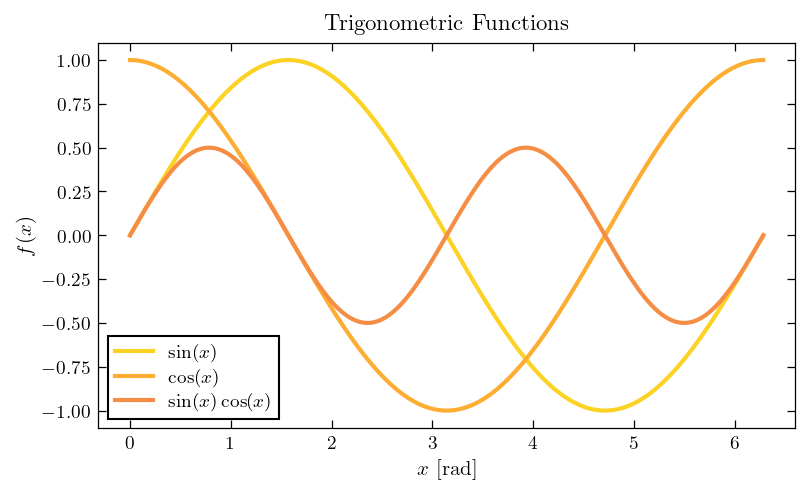

In [2]:
x = np.linspace(0, 2 * np.pi, 200)

fig, ax = mpl_plt.subplots()

plt.plot_styled(x, np.sin(x), label=r'$\sin(x)$', color_idx=0, ax=ax)
plt.plot_styled(x, np.cos(x), label=r'$\cos(x)$', color_idx=1, ax=ax)
plt.plot_styled(x, np.sin(x) * np.cos(x), label=r'$\sin(x)\cos(x)$', color_idx=2, ax=ax)

plt.setup_axis(ax, xlabel=r'$x$ [rad]', ylabel=r'$f(x)$',
               title=r'Trigonometric Functions')
ax.legend()
mpl_plt.tight_layout()
mpl_plt.show()

## 3 · Rich Math in Labels

The LaTeX preset loads `amsmath` and `amssymb`, so you can use full LaTeX math notation.

/var/folders/j5/tt5khs650k572nn7s6tzk2jr0000gp/T/ipykernel_94973/1558104509.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axes = mpl_plt.subplots(1, 2, figsize=(5.5 * 2, 5.5 * 0.618))
/Users/i.sokolov/Code/pltx/pltx/style.py:248: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_xscale(xscale)
/Users/i.sokolov/Code/pltx/pltx/style.py:249: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_yscale(yscale)


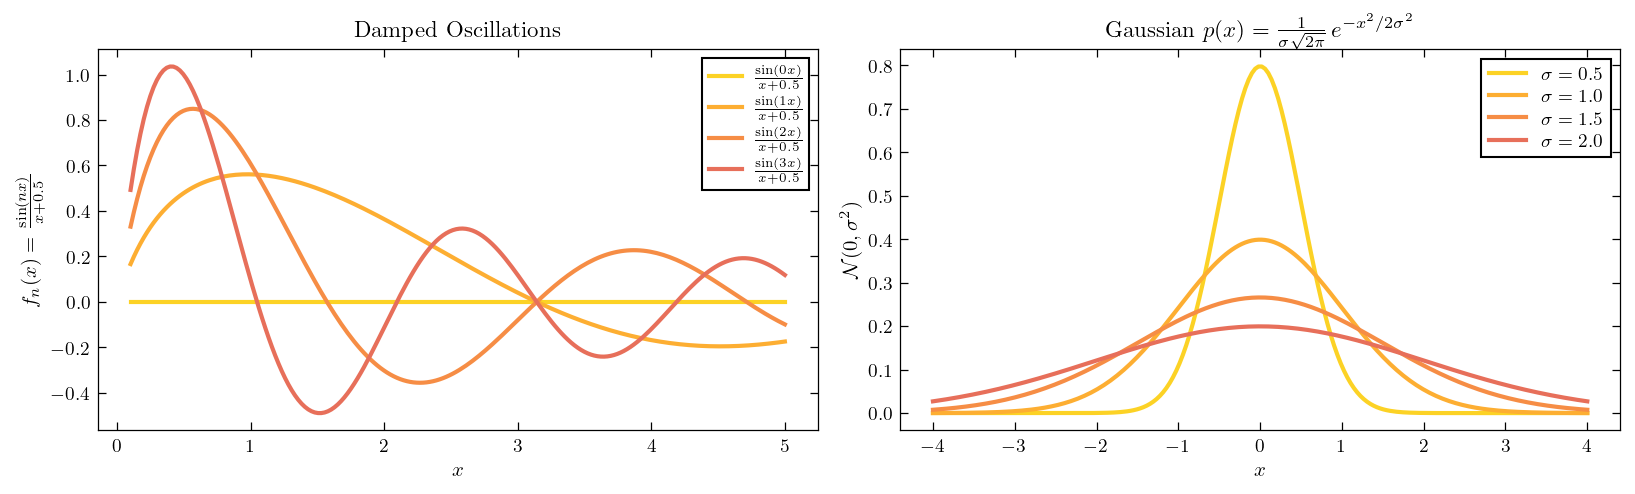

In [3]:
x = np.linspace(0.1, 5, 200)

fig, axes = mpl_plt.subplots(1, 2, figsize=(5.5 * 2, 5.5 * 0.618))

# Left: Bessel-like functions
ax = axes[0]
for n in range(4):
    y = np.sin(n * x) / (x + 0.5)
    plt.plot_styled(x, y, color_idx=n, ax=ax,
                    label=r'$\frac{\sin(%d x)}{x + 0.5}$' % n)
plt.setup_axis(ax, xlabel=r'$x$',
               ylabel=r'$f_n(x) = \frac{\sin(nx)}{x + 0.5}$',
               title=r'Damped Oscillations')
ax.legend(fontsize=8)

# Right: Gaussian with varying sigma
ax = axes[1]
plt.reset_color_cycle()
x2 = np.linspace(-4, 4, 200)
for sigma in [0.5, 1.0, 1.5, 2.0]:
    y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x2**2 / (2 * sigma**2))
    plt.plot_styled(x2, y, ax=ax,
                    label=r'$\sigma = %.1f$' % sigma)
plt.setup_axis(ax, xlabel=r'$x$',
               ylabel=r'$\mathcal{N}(0, \sigma^2)$',
               title=r'Gaussian $p(x) = \frac{1}{\sigma\sqrt{2\pi}}\,e^{-x^2/2\sigma^2}$')
ax.legend()

mpl_plt.tight_layout()
mpl_plt.show()

## 4 · Scatter + Error Bars

Publication-quality data plots with LaTeX-rendered annotations.

/var/folders/j5/tt5khs650k572nn7s6tzk2jr0000gp/T/ipykernel_94973/1278230640.py:8: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = mpl_plt.subplots()
/Users/i.sokolov/Code/pltx/pltx/style.py:248: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_xscale(xscale)
/Users/i.sokolov/Code/pltx/pltx/style.py:249: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_yscale(yscale)


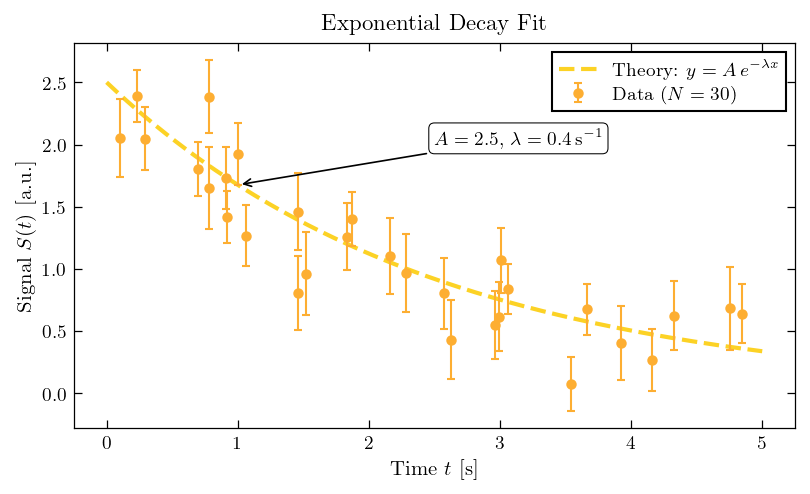

In [4]:
# Simulated experimental data
N = 30
x_data = np.sort(np.random.uniform(0, 5, N))
y_true = 2.5 * np.exp(-0.4 * x_data)
y_data = y_true + 0.3 * np.random.randn(N)
y_err = 0.2 + 0.15 * np.random.rand(N)

fig, ax = mpl_plt.subplots()

plt.reset_color_cycle()

# Theory curve
x_fine = np.linspace(0, 5, 200)
plt.plot_styled(x_fine, 2.5 * np.exp(-0.4 * x_fine), ax=ax, color_idx=0,
                label=r'Theory: $y = A\,e^{-\lambda x}$', linestyle='--')

# Experimental data with error bars
from pltx.colors import get_color
ax.errorbar(x_data, y_data, yerr=y_err, fmt='o', color=get_color(1),
            markersize=4, capsize=2, linewidth=1,
            label=r'Data ($N=%d$)' % N)

plt.setup_axis(ax, xlabel=r'Time $t$ [s]',
               ylabel=r'Signal $S(t)$ [a.u.]',
               title=r'Exponential Decay Fit')
ax.legend()

# Add annotation with LaTeX
ax.annotate(r'$A = 2.5$, $\lambda = 0.4\,\mathrm{s}^{-1}$',
            xy=(1.0, 2.5 * np.exp(-0.4)),
            xytext=(2.5, 2.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.5))

mpl_plt.tight_layout()
mpl_plt.show()

## 5 · Heatmap with LaTeX Colorbar

2-D data with a LaTeX-styled colorbar label.

/var/folders/j5/tt5khs650k572nn7s6tzk2jr0000gp/T/ipykernel_94973/322553378.py:4: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = mpl_plt.subplots()
/var/folders/j5/tt5khs650k572nn7s6tzk2jr0000gp/T/ipykernel_94973/322553378.py:7: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
/Users/i.sokolov/Code/pltx/pltx/style.py:248: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_xscale(xscale)
/Users/i.sokolov/Code/pltx/pltx/style.py:249: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_yscale(yscale)


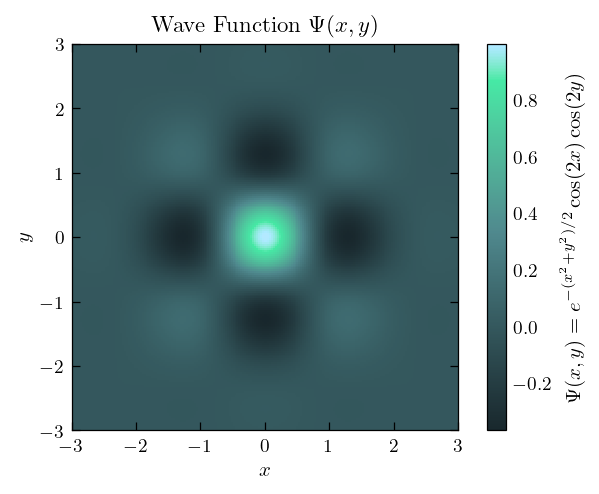

In [5]:
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = np.exp(-(grid_x**2 + grid_y**2) / 2) * np.cos(2 * grid_x) * np.cos(2 * grid_y)

fig, ax = mpl_plt.subplots()
im = ax.imshow(Z, cmap='pasqal', origin='lower',
               extent=[-3, 3, -3, 3], aspect='equal')
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'$\Psi(x,y) = e^{-(x^2+y^2)/2}\cos(2x)\cos(2y)$')

plt.setup_axis(ax, xlabel=r'$x$', ylabel=r'$y$',
               title=r'Wave Function $\Psi(x, y)$')

mpl_plt.tight_layout()
mpl_plt.show()

## 6 · Multi-Panel Figure

A typical multi-panel layout for a journal paper, with LaTeX panel labels.

/var/folders/j5/tt5khs650k572nn7s6tzk2jr0000gp/T/ipykernel_94973/3679832588.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axes = mpl_plt.subplots(2, 2, figsize=(5.5 * 2, 5.5 * 0.618 * 2))
/Users/i.sokolov/Code/pltx/pltx/style.py:248: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_xscale(xscale)
/Users/i.sokolov/Code/pltx/pltx/style.py:249: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_yscale(yscale)


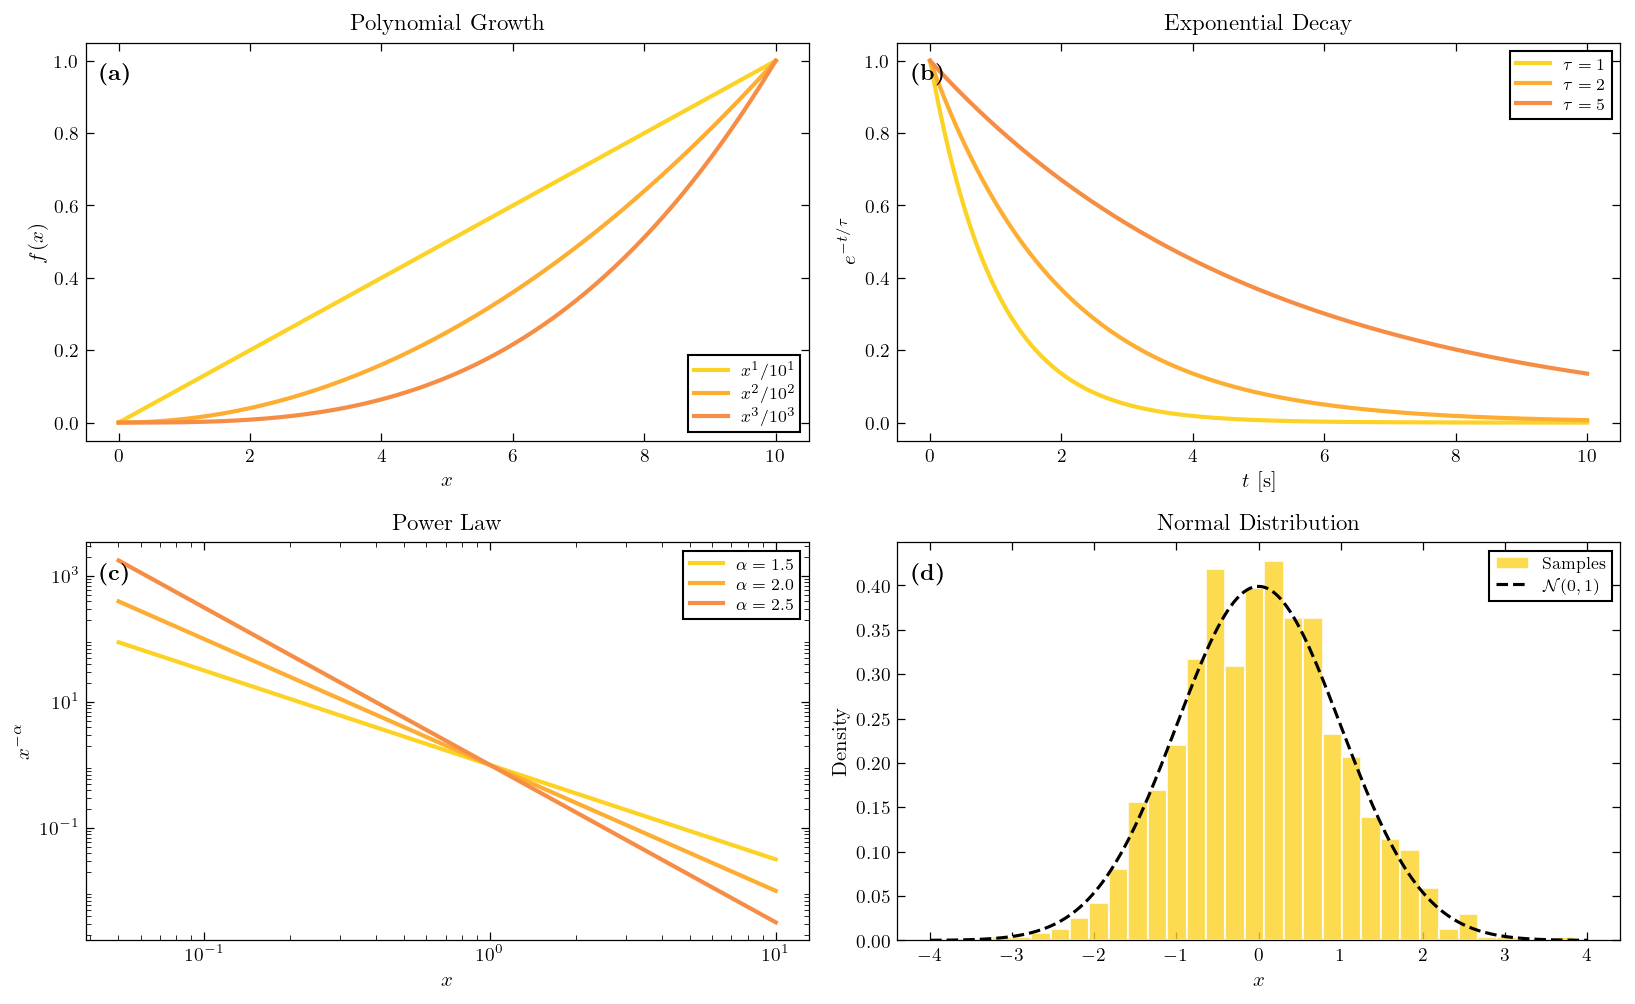

In [6]:
fig, axes = mpl_plt.subplots(2, 2, figsize=(5.5 * 2, 5.5 * 0.618 * 2))

x = np.linspace(0, 10, 200)

# (a) Polynomial growth
ax = axes[0, 0]
plt.reset_color_cycle()
for n in [1, 2, 3]:
    plt.plot_styled(x, x**n / 10**n, ax=ax, label=r'$x^%d / 10^%d$' % (n, n))
plt.setup_axis(ax, xlabel=r'$x$', ylabel=r'$f(x)$', title=r'Polynomial Growth')
ax.legend(fontsize=8)
ax.text(0.02, 0.95, r'\textbf{(a)}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top')

# (b) Exponential decay
ax = axes[0, 1]
plt.reset_color_cycle()
for tau in [1, 2, 5]:
    plt.plot_styled(x, np.exp(-x / tau), ax=ax, label=r'$\tau = %d$' % tau)
plt.setup_axis(ax, xlabel=r'$t$ [s]', ylabel=r'$e^{-t/\tau}$',
               title=r'Exponential Decay')
ax.legend(fontsize=8)
ax.text(0.02, 0.95, r'\textbf{(b)}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top')

# (c) Log scale
ax = axes[1, 0]
plt.reset_color_cycle()
for alpha in [1.5, 2.0, 2.5]:
    plt.plot_styled(x[1:], x[1:]**(-alpha), ax=ax,
                    label=r'$\alpha = %.1f$' % alpha)
plt.setup_axis(ax, xlabel=r'$x$', ylabel=r'$x^{-\alpha}$',
               title=r'Power Law', xscale='log', yscale='log')
ax.legend(fontsize=8)
ax.text(0.02, 0.95, r'\textbf{(c)}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top')

# (d) Histogram
ax = axes[1, 1]
plt.reset_color_cycle()
data = np.random.normal(0, 1, 1000)
ax.hist(data, bins=30, color=plt.get_style().get_color(0), edgecolor='white',
        alpha=0.8, density=True, label=r'Samples')
x_gauss = np.linspace(-4, 4, 200)
ax.plot(x_gauss, (1/np.sqrt(2*np.pi)) * np.exp(-x_gauss**2/2),
        'k--', linewidth=1.5, label=r'$\mathcal{N}(0,1)$')
plt.setup_axis(ax, xlabel=r'$x$', ylabel=r'Density',
               title=r'Normal Distribution')
ax.legend(fontsize=8)
ax.text(0.02, 0.95, r'\textbf{(d)}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top')

mpl_plt.tight_layout()
mpl_plt.show()

## 7 · Saving for LaTeX

Use `savefig` to produce a PDF that can be included in your LaTeX document with `\\includegraphics`.

```latex
\begin{figure}[ht]
    \centering
    \includegraphics[width=\textwidth]{my_figure.pdf}
    \caption{Figure produced with pltx LaTeX preset.}
    \label{fig:example}
\end{figure}
```

/var/folders/j5/tt5khs650k572nn7s6tzk2jr0000gp/T/ipykernel_94973/2754082811.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = mpl_plt.subplots()
/Users/i.sokolov/Code/pltx/pltx/style.py:248: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_xscale(xscale)
/Users/i.sokolov/Code/pltx/pltx/style.py:249: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax.set_yscale(yscale)


Saved: latex_example.pdf
Figure size: [5.5   3.399] inches


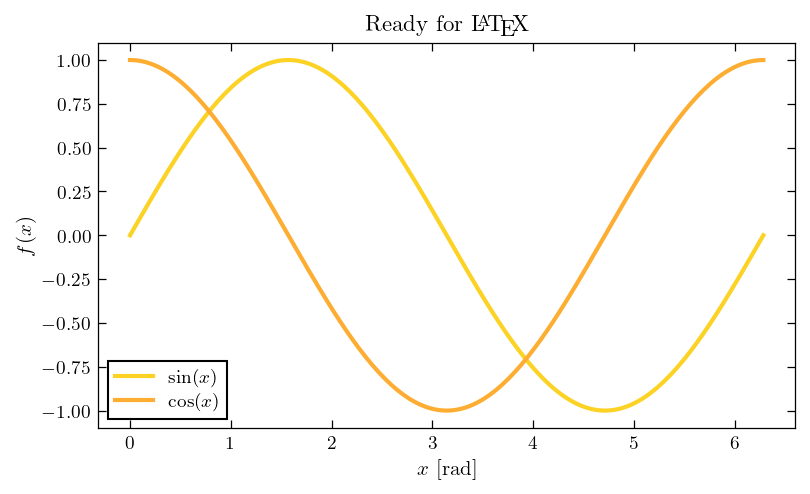

Bad pipe message: %s [b"=\x9f\x05\x80F\xf4\xe0)r\x84\xe3\x8dX\x15\xf8\x01\x07O \xbc\x19v\n\x8f0\x13\x00\xa6\x19\r~k\xaaY\xb6\xf1,\xf0_\xb4\x05\x9e\xddGKl`\xd8\x16\xac\xea\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0", b'\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01']
Bad pipe message: %s [b'\xc6\xbb\x12\x994\xf2\xcb\xe9\n']
Bad pipe message: %s [b'&\x87\xdf\x1a\x07\xea\x8eIc\x07\x83\xa9\xb3\x8f', b"\x0b\x9d \xe8\x8f\x90\xb1swX\xcc\xc7IMd\x8d\x00\x9a\xdb\x8bn\x0b\xd8\nA\\\xc6\xf4J$\xb9\xfc\xd5'\x93\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00\x06\x00\x1d\x00\x17\x00\x18\x00\x0b\x00\x02\x01\x00\x00#\x00\x00\x00\r\x00\x14\x00\x12"]
Bad pipe message: %s [b'\x08\x04\x04', b'', b'\x05\x05']
Bad pipe message: %s [b'']
Bad pipe message: %s [b'\x01\x02\x01\x003']
ERROR:tornado.gene

In [7]:
# Example: save a figure for LaTeX inclusion
fig, ax = mpl_plt.subplots()

plt.reset_color_cycle()
x = np.linspace(0, 2 * np.pi, 200)
plt.plot_styled(x, np.sin(x), label=r'$\sin(x)$', ax=ax)
plt.plot_styled(x, np.cos(x), label=r'$\cos(x)$', ax=ax)
plt.setup_axis(ax, xlabel=r'$x$ [rad]', ylabel=r'$f(x)$',
               title=r'Ready for \LaTeX')
ax.legend()
mpl_plt.tight_layout()

# Saves as PDF at 300 DPI with tight bounding box (preset defaults)
fig.savefig('latex_example.pdf')
print('Saved: latex_example.pdf')
print(f'Figure size: {fig.get_size_inches()} inches')